# Task 1: Potential Problems in Linear Regression
In this task, we will explore common problems that may arise when fitting a linear regression model and use generative AI to create examples that illustrate these issues.

The six common issues that arise when fitting a linear model are:

- Non-linearity of the response-predictor relationships
- Correlation of error terms
- Non-constant variance of error terms
- Outliers
- High-leverage points
- Collinearity

## Set up

In [1]:
# Load all necessary libraries
import os
import numpy as np                      
import pandas as pd                     
import matplotlib.pyplot as plt         
import matplotlib.gridspec as gridspec 

# Scikit-learn: machine learning tools
from sklearn.linear_model import LinearRegression    # fits linear regression models
from sklearn.preprocessing import PolynomialFeatures # creates X^2, X^3, etc. from X
from sklearn.pipeline import make_pipeline           # chains preprocessing + model into one step

# Statsmodels: classical statistics tools
from statsmodels.stats.outliers_influence import variance_inflation_factor  # computes VIF for collinearity detection
import statsmodels.api as sm            # full regression summaries, influence statistics
from scipy.ndimage import uniform_filter1d  # smoothing function for residual trend line

import warnings
warnings.filterwarnings('ignore')       # suppress non-critical warnings to keep output clean

# Set a random seed so synthetic data is reproducible across runs
np.random.seed(42)

# Create figures directory
os.makedirs('task1/figures', exist_ok=True)


## Selection of three issues
I seclect the following three issues for indepth understanding and analysis
- Non-linearity of the response-predictor relationships
- Outliers
- Collinearity

---

### Issue 1: Non-linearity of the response-predictor relationships

#### What is it?

Linear regression assumes there is a straight-line relationship between the predictors and the response. If the true relationship is far from linear, virtually all of the conclusions we draw from the fit are suspect, and the prediction accuracy of the model can be significantly reduced.

#### How do you detect it?

Residual plots are a useful tool for identifying non-linearity. For a simple linear regression, we plot the residuals against the predictor. For a multiple regression model, we plot them against the fitted values instead. If the model fits well, the residual plot should show no discernible pattern. A clear U-shape in the residuals is a strong indication of non-linearity. The book demonstrates this with the auto dataset: regressing mpg on horsepower alone produces a U-shaped residual plot. Adding a horsepower^2 term removes the pattern, suggesting a much better fit.

#### How to address it?

A simple approach is to use non-linear transformations of the predictors in the regression model such as log(X), sqrt(X), or X^2.

#### Question I had while reading

Q: The book lists log(X), sqrt(X) and X^2 as possible fixes but how to know which one to try first?

- The book does not give a specific rule for this. What it does say is that the residual plot is the main diagnostic tool, if adding a transformation removes the pattern from the residuals, that transformation is working. In practice, we can try a few options, check the residual plot each time and go with whichever one leaves the residuals with no clear pattern.

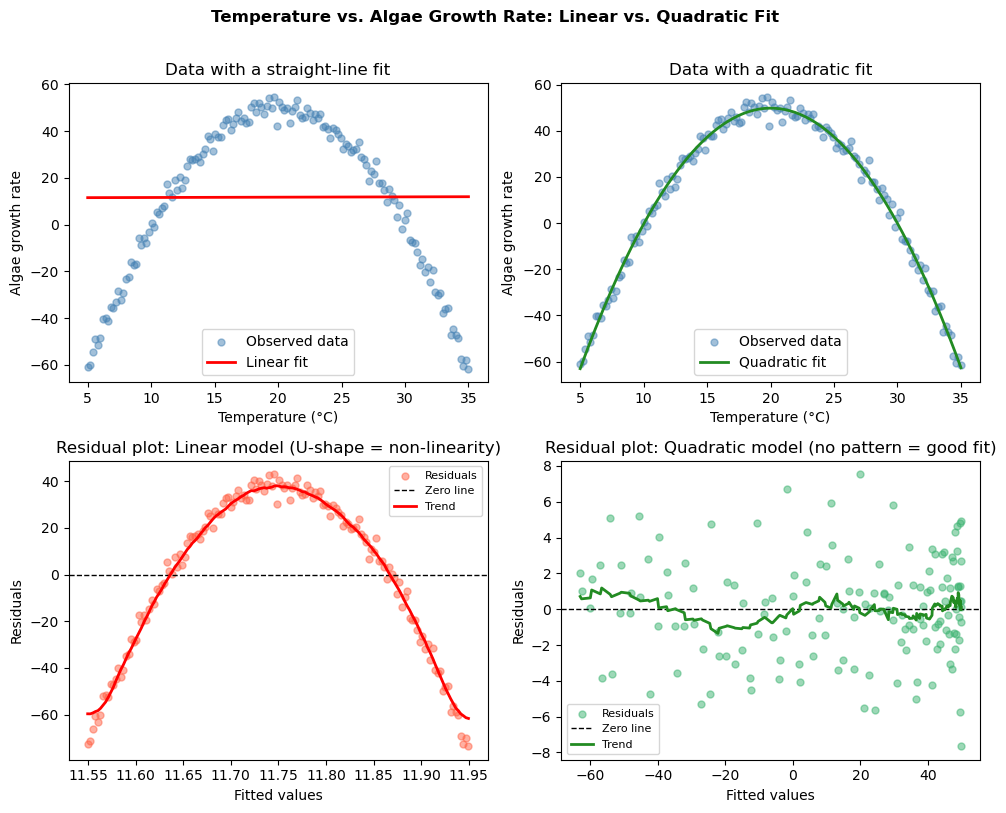

Figure saved.


In [ ]:
# --- Generate synthetic data with a curved (quadratic) relationship ---
# Example: Temperature (X) is used to predict algae growth rate (Y), where growth peaks at moderate temperatures and drops at the extremes.

# Generate 150 observations of temperature (X) and algae growth rate (Y)
n = 150
X = np.linspace(5, 35, n) # temperature range (°C)
noise = np.random.normal(0, 3, n)
Y = -0.5 * (X - 20)**2 + 50 + noise # true relationship is a downward parabola

# Reshape X into a column for scikit-learn
X_reshaped = X.reshape(-1, 1)

# Fit a LINEAR model (wrong model)
lin_model = LinearRegression()
lin_model.fit(X_reshaped, Y)
Y_pred_lin = lin_model.predict(X_reshaped)
residuals_lin = Y - Y_pred_lin

# Fit a QUADRATIC model (correct model)
quad_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
quad_model.fit(X_reshaped, Y)
Y_pred_quad = quad_model.predict(X_reshaped)
residuals_quad = Y - Y_pred_quad

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Temperature vs. Algae Growth Rate: Linear vs. Quadratic Fit', fontsize=12, fontweight='bold', y=1.01)

# Top-left: data with linear fit
axes[0, 0].scatter(X, Y, alpha=0.5, color='steelblue', s=25, label='Observed data')
axes[0, 0].plot(X, Y_pred_lin, color='red', linewidth=2, label='Linear fit')
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Algae growth rate')
axes[0, 0].set_title('Data with a straight-line fit')
axes[0, 0].legend()

# Top-right: data with quadratic fit
axes[0, 1].scatter(X, Y, alpha=0.5, color='steelblue', s=25, label='Observed data')
axes[0, 1].plot(X, Y_pred_quad, color='forestgreen', linewidth=2, label='Quadratic fit')
axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].set_ylabel('Algae growth rate')
axes[0, 1].set_title('Data with a quadratic fit')
axes[0, 1].legend()

# Bottom-left: residual plot for linear model
axes[1, 0].scatter(Y_pred_lin, residuals_lin, alpha=0.5, color='tomato', s=25, label='Residuals')
axes[1, 0].axhline(0, color='black', linewidth=1, linestyle='--', label='Zero line')
# Smooth trend line through residuals
sorted_idx = np.argsort(Y_pred_lin)
smooth_resid_lin = uniform_filter1d(residuals_lin[sorted_idx], size=20)
axes[1, 0].plot(Y_pred_lin[sorted_idx], smooth_resid_lin, color='red', linewidth=2, label='Trend')
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual plot: Linear model (U-shape = non-linearity)')
axes[1, 0].legend(fontsize=8)

# Bottom-right: residual plot for quadratic model
sorted_idx2 = np.argsort(Y_pred_quad)
smooth_resid_quad = uniform_filter1d(residuals_quad[sorted_idx2], size=20)
axes[1, 1].scatter(Y_pred_quad, residuals_quad, alpha=0.5, color='mediumseagreen', s=25, label='Residuals')
axes[1, 1].axhline(0, color='black', linewidth=1, linestyle='--', label='Zero line')
axes[1, 1].plot(Y_pred_quad[sorted_idx2], smooth_resid_quad, color='forestgreen', linewidth=2, label='Trend')
axes[1, 1].set_xlabel('Fitted values')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residual plot: Quadratic model (no pattern = good fit)')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/issue1_nonlinearity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

**Figure caption:** The top row shows algae growth rate versus temperature. The straight-line fit (top left) does not follow the curved pattern in the data, while adding a temperature^2 term (top right) follows it much more closely. The bottom row shows residual plots for each model. With the straight-line fit, the residuals form a clear U-shape, which is a strong sign of non-linearity. After adding the temperature^2 term, the residuals show no clear pattern, which means the fit has improved.

---

### Issue 2: Outliers

#### What is it?

An outlier is a data point where the observed response (Y) is very far from what the model predicts. Outliers can happen for various reasons, such as incorrect recording of an observation during data collection.

#### Why does it matter?

Even if an outlier does not change the regression line much, it can still cause problems. For example, it inflates the Residual Standard Error (RSE), which is used to compute all confidence intervals and p-values. It also causes R^2 to decline. The book shows this clearly: including one outlier raised the RSE from 0.77 to 1.09, and dropped R^2 from 0.892 to 0.805.

#### How do you detect it?

Residual plots can help identify outliers, but it can be difficult to decide how large a residual needs to be before we consider a point an outlier. A better approach is to use studentized residuals, each residual divided by its estimated standard error. Observations whose studentized residuals are greater than 3 in absolute value are possible outliers.

#### How do you address it?

If the outlier occurred due to an error in data collection or recording, removing it is one option. However, care should be taken, since an outlier may instead indicate a problem with the model itself, such as a missing predictor.

#### Question I had while reading

Q: What is the difference between an outlier and a high-leverage point? Can a point be both?

- An outlier is a point where the response Y is unusual given the predictor X. It has a large residual.
- A high-leverage point is a point where the predictor X itself is unusual. It sits far from the range of the other X values.

A point can be both, and the book describes this as a particularly dangerous combination, since such a point can heavily affect the regression line while also being poorly fit by it.

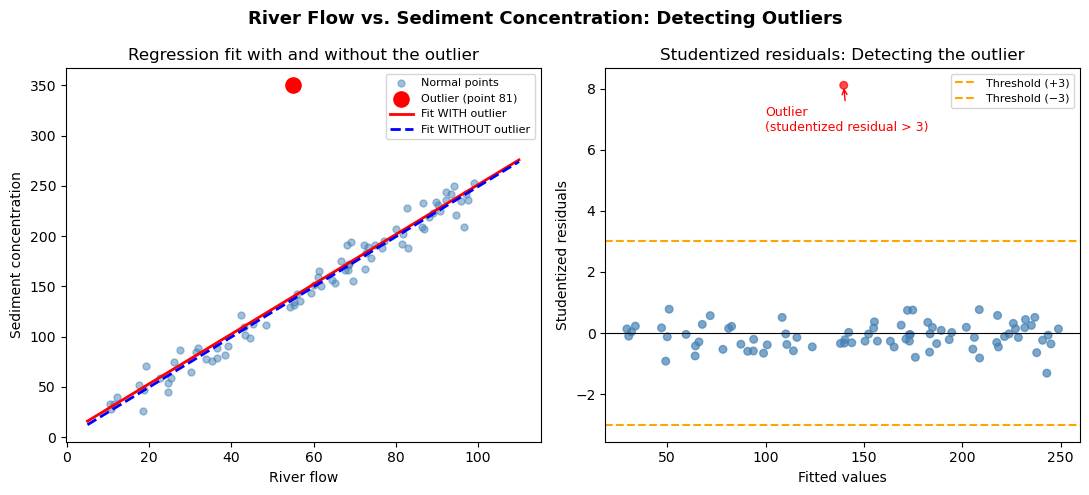

RSE without outlier: 10.75
RSE with outlier:    26.09
R² without outlier: 0.974
R² with outlier:    0.862


In [3]:
# --- Generate data with one clear outlier ---
# Example: River flow (X) is used to predict sediment concentration (Y).

# Generate 80 observations of river flow (X) and sediment concentration (Y)
n = 80
X2 = np.random.uniform(10, 100, n)
Y2 = 2.5 * X2 + np.random.normal(0, 10, n)

# Add a single outlier: normal X value, very extreme Y
X2_with_outlier = np.append(X2, 55)
Y2_with_outlier = np.append(Y2, 350)   # far above the trend

X2r = X2.reshape(-1, 1)             # clean data (no outlier)
X2o = X2_with_outlier.reshape(-1, 1) # data with outlier

# Fit models with and without outlier
model_clean = LinearRegression().fit(X2r, Y2)
model_outlier = LinearRegression().fit(X2o, Y2_with_outlier)

# Generate smooth regression lines for plotting
x_line    = np.linspace(5, 110, 200).reshape(-1, 1)
y_clean   = model_clean.predict(x_line)    # predicted line without outlier
y_outlier = model_outlier.predict(x_line)  # predicted line with outlier

# Compute studentized residuals using statsmodels
X2o_sm = sm.add_constant(X2_with_outlier)
sm_model = sm.OLS(Y2_with_outlier, X2o_sm).fit()
influence = sm_model.get_influence()
studentized_resids = influence.resid_studentized_internal
fitted_vals = sm_model.fittedvalues

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('River Flow vs. Sediment Concentration: Detecting Outliers', fontsize=13, fontweight='bold')

# Left: scatter with both regression lines
axes[0].scatter(X2, Y2, alpha=0.5, color='steelblue', s=25, label='Normal points')
axes[0].scatter(55, 350, color='red', s=120, zorder=5, label='Outlier (point 81)')
axes[0].plot(x_line, y_outlier, color='red', linewidth=2, linestyle='-', label='Fit WITH outlier')
axes[0].plot(x_line, y_clean, color='blue', linewidth=2, linestyle='--', label='Fit WITHOUT outlier')
axes[0].set_xlabel('River flow')
axes[0].set_ylabel('Sediment concentration')
axes[0].set_title('Regression fit with and without the outlier')
axes[0].legend(fontsize=8)

# Right: studentized residuals vs fitted values
colors = ['red' if i == len(X2_with_outlier) - 1 else 'steelblue' for i in range(len(X2_with_outlier))]
axes[1].scatter(fitted_vals, studentized_resids, c=colors, s=30, alpha=0.7)
axes[1].axhline(3, color='orange', linestyle='--', linewidth=1.5, label='Threshold (+3)')
axes[1].axhline(-3, color='orange', linestyle='--', linewidth=1.5, label='Threshold (−3)')
axes[1].axhline(0, color='black', linewidth=0.8)
# Label the outlier
outlier_idx = np.argmax(np.abs(studentized_resids))
axes[1].annotate('Outlier\n(studentized residual > 3)',
                 xy=(fitted_vals[outlier_idx], studentized_resids[outlier_idx]),
                 xytext=(fitted_vals[outlier_idx] - 40, studentized_resids[outlier_idx] - 1.5),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=9)
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Studentized residuals')
axes[1].set_title('Studentized residuals: Detecting the outlier')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/issue2_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# Print RSE comparison
rse_clean = np.sqrt(np.sum((Y2 - model_clean.predict(X2r))**2) / (len(Y2) - 2))
rse_outlier = np.sqrt(np.sum((Y2_with_outlier - model_outlier.predict(X2o))**2) / (len(Y2_with_outlier) - 2))
print(f'RSE without outlier: {rse_clean:.2f}')
print(f'RSE with outlier:    {rse_outlier:.2f}')
print(f'R² without outlier: {model_clean.score(X2r, Y2):.3f}')
print(f'R² with outlier:    {model_outlier.score(X2o, Y2_with_outlier):.3f}')

**Figure caption:** The left panel shows river flow versus sediment concentration, with one extreme outlier added (red dot). The blue dashed line is the fit without the outlier, and the red line includes it. The outlier barely shifts the line but raises the RSE and lowers R^2. The right panel plots studentized residuals against fitted values. The outlier stands far above the +3 threshold (orange dashed line), making it easy to spot. All other points fall within the ±3 range.

---

### Issue 3: Collinearity

#### What is it?

Collinearity means that two or more predictor variables are closely related to one another. The book explains this with the Credit dataset, where `limit` and `rating` are highly correlated. When two predictors move together, it is difficult to separate out their individual effects on the response.

#### Why does it matter?

Collinearity reduces the accuracy of the coefficient estimates and causes their standard errors to grow. As a result, the t-statistic for each predictor gets smaller and the p-value gets larger. This means a predictor that actually matters might appear non-significant, this is called a reduction in the power of the hypothesis test. For example, in a regression of balance on `limit` and `rating`, the standard error of the `limit` coefficient increases by a factor of 12, and its p-value rises to 0.701.

#### How do you detect it?

A simple first step is to look at the correlation matrix of the predictors. A large value indicates a pair of highly correlated variables. However, collinearity can also exist among three or more variables even when no single pair has a high correlation, this is called multicollinearity. A better tool is the Variance Inflation Factor (VIF). A VIF above 5 or 10 indicates a problematic amount of collinearity. In the Credit dataset, `rating` and `limit` have VIF values of around 160, which confirms the problem.

#### How do you address it?

There are two solutions. The first is to drop one of the collinear variables, since they carry redundant information, removing one usually causes very little loss in model fit. For example, dropping `rating` barely changed R^2 (from 0.754 to 0.75) but brought the VIF values back down to near 1. The second option is to combine the collinear variables into a single new predictor, such as taking the average of standardized versions of `limit` and `rating`.

#### Question I had while reading

Q: The book says collinearity creates a "narrow valley" in the RSS contour plot, what does that mean exactly?

- The book shows this with a contour plot. When two predictors are not collinear, the RSS contours form a round shape with a clear lowest point, so the best coefficient estimates are easy to find. When two predictors are collinear, the contours form a long narrow valley, many different combinations of the two coefficients give nearly the same RSS value. This means a small change in the data can shift the best estimates anywhere along that valley, which is why the estimates become unstable and their standard errors grow large.

In [4]:
# --- Generate data with collinear predictors ---
# Example: temperature (X1), vegetation dryness index (X2), and wind speed (X3) are used to predict wildfire risk,
        # where temperature and dryness are highly correlated with each other
        # wind speed is independent.

# Generate 200 observations of temperature, dryness, wind speed and wildfire risk
n = 200
temperature = np.random.normal(30, 5, n)                  # temperature (°C)
dryness = 0.95 * temperature + np.random.normal(0, 1, n)  # dryness is nearly a linear function of temperature
wind = np.random.normal(15, 4, n)                         # wind speed is independent of temperature
noise = np.random.normal(0, 5, n)

# True relationship: only temperature and wind affect wildfire risk (dryness is redundant)
wildfire_risk = 2 * temperature + 1.5 * wind + noise

# Store all variables in a dataframe
df = pd.DataFrame({'temperature': temperature, 'dryness': dryness,
                   'wind': wind, 'wildfire_risk': wildfire_risk})

# Compute VIF 
X_vif = sm.add_constant(df[['temperature', 'dryness', 'wind']])
vif_data = pd.DataFrame()
vif_data['Predictor'] = ['temperature', 'dryness', 'wind']
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i+1) for i in range(3)]
print("VIF values (>5 or >10 = problematic collinearity):")
print(vif_data.to_string(index=False))

# Fit full model (with collinear predictors)
X_full = sm.add_constant(df[['temperature', 'dryness', 'wind']])
model_full = sm.OLS(df['wildfire_risk'], X_full).fit()

# Fit reduced model (drop dryness)
X_reduced = sm.add_constant(df[['temperature', 'wind']])
model_reduced = sm.OLS(df['wildfire_risk'], X_reduced).fit()

print("\nCoefficients — full model (with collinear dryness):")
print(model_full.summary2().tables[1][['Coef.', 'Std.Err.', 't', 'P>|t|']].iloc[1:])
print("\nCoefficients — reduced model (dryness removed):")
print(model_reduced.summary2().tables[1][['Coef.', 'Std.Err.', 't', 'P>|t|']].iloc[1:])

VIF values (>5 or >10 = problematic collinearity):
  Predictor       VIF
temperature 23.135726
    dryness 23.160051
       wind  1.012234

Coefficients — full model (with collinear dryness):
                Coef.  Std.Err.          t         P>|t|
temperature  2.149109  0.336703   6.382806  1.229804e-09
dryness     -0.150053  0.340920  -0.440141  6.603196e-01
wind         1.682200  0.089133  18.873019  5.829293e-46

Coefficients — reduced model (dryness removed):
                Coef.  Std.Err.          t         P>|t|
temperature  2.004150  0.069863  28.686965  2.887218e-72
wind         1.677912  0.088417  18.977234  2.374130e-46


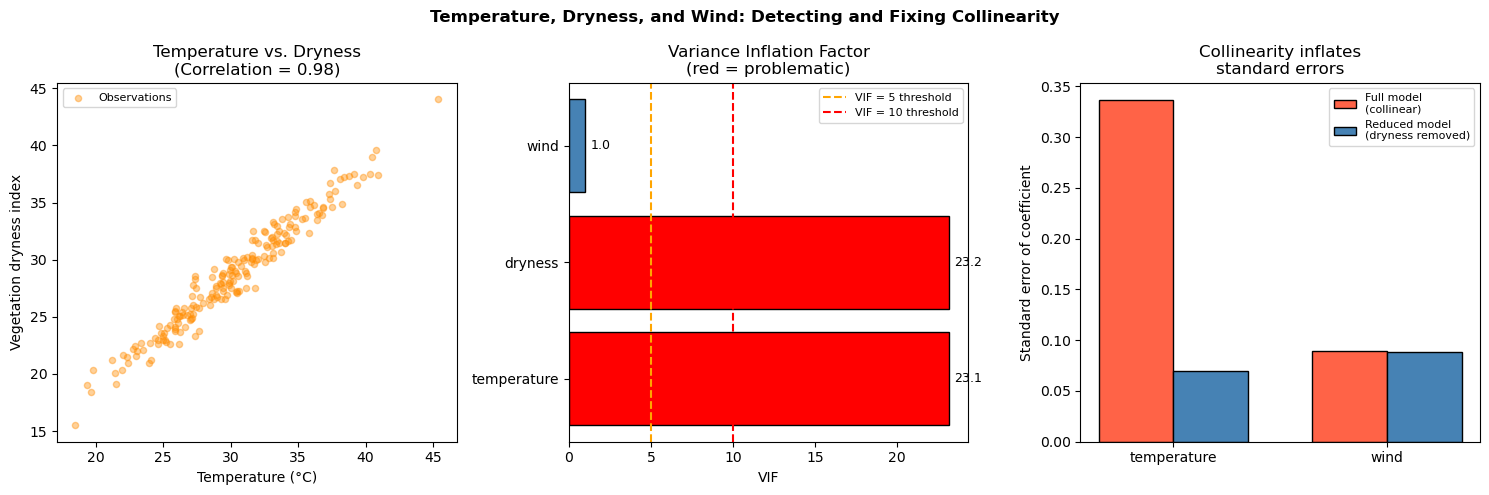

In [5]:
# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Temperature, Dryness, and Wind: Detecting and Fixing Collinearity', fontsize=12, fontweight='bold')

# Left: scatter of temperature vs dryness — shows collinearity
axes[0].scatter(temperature, dryness, alpha=0.4, color='darkorange', s=20, label='Observations')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Vegetation dryness index')
axes[0].set_title(f'Temperature vs. Dryness\n(Correlation = {np.corrcoef(temperature, dryness)[0,1]:.2f})')
axes[0].legend(fontsize=8)

# Middle: bar chart of VIF values
colors_vif = ['red' if v > 5 else 'steelblue' for v in vif_data['VIF']]
bars = axes[1].barh(vif_data['Predictor'], vif_data['VIF'], color=colors_vif, edgecolor='black')
axes[1].axvline(5, color='orange', linestyle='--', linewidth=1.5, label='VIF = 5 threshold')
axes[1].axvline(10, color='red', linestyle='--', linewidth=1.5, label='VIF = 10 threshold')
axes[1].set_xlabel('VIF')
axes[1].set_title('Variance Inflation Factor\n(red = problematic)')
axes[1].legend(fontsize=8)
for bar, val in zip(bars, vif_data['VIF']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

# Right: compare standard errors between full vs reduced model
se_full = model_full.bse[['temperature', 'wind']]
se_reduced = model_reduced.bse[['temperature', 'wind']]
x_pos = np.arange(2)
width = 0.35
axes[2].bar(x_pos - width/2, se_full.values, width, label='Full model\n(collinear)', color='tomato', edgecolor='black')
axes[2].bar(x_pos + width/2, se_reduced.values, width, label='Reduced model\n(dryness removed)', color='steelblue', edgecolor='black')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(['temperature', 'wind'])
axes[2].set_ylabel('Standard error of coefficient')
axes[2].set_title('Collinearity inflates\nstandard errors')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/issue3_collinearity.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure caption:** The left figure shows that the temperature and vegetation dryness are nearly perfectly correlated (r ≈ 0.98), which means they are collinear. The middle figure shows the VIF for each variable: temperature and dryness have VIFs far above the threshold of 5–10 (red bars), while wind speed has a VIF near 1 since it is independent. The right figure compares the standard errors of the temperature and wind coefficients between the full model (with dryness) and the reduced model (dryness removed). Removing dryness brings the standard errors down, making the coefficient estimates more reliable.

---

## Generative AI Reflection

For this task, I used Claude (claude.ai) to generate the Python code that produces the synthetic datasets and plots. My prompts described each issue in plain terms and asked for environmental variable names to keep the examples relevant to my field.

It took about 6-7 iterations per issue to get clean, working code. For the outliers section, Claude initially used `scipy.stats.zscore` to compute studentized residuals. I went back to the textbook and asked Claude to use `statsmodels` `get_influence()` method instead. For the collinearity section, Claude's first attempt used `seaborn` for the VIF bar chart, but I asked it to use `matplotlib` to keep the code consistent across all plots. Additionally, Claude placed the `from scipy.ndimage import uniform_filter1d` import inside the plotting block rather than at the top of the notebook with all other imports. I moved it to the top to keep the code clean and organized. I also refined the plots across all three issues by adjusting figure sizes, layout spacing, and font sizes to make them clearer and easier to read. All written explanations and questions are mine and I used the textbook as the main source.